# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

#  Load Dataset

In [4]:
df=pd.read_csv(r"C:\Users\Aamir choudhary\OneDrive\Desktop\Breast_Cancer.csv")

df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


# 
Dataset information

In [5]:
df.shape

(4024, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [7]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


# Missing Values Check

In [8]:
df.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

# Duplicate Values

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df.drop_duplicates(inplace=True)

# EDA Visualization

# Status distribution

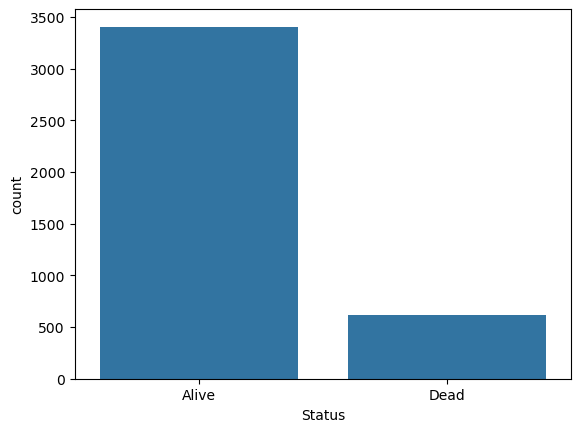

In [11]:
sns.countplot(x="Status",data=df)

plt.show()

# Age distribution

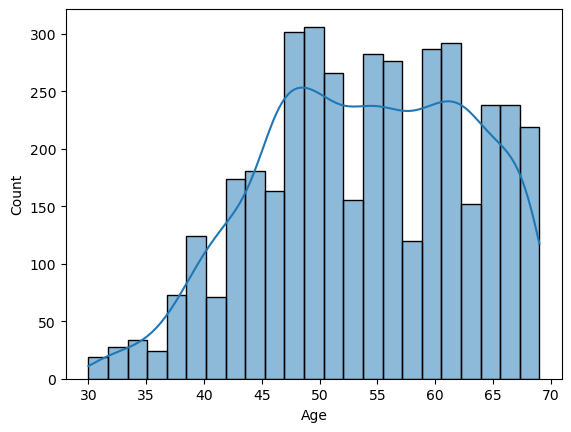

In [12]:
sns.histplot(df["Age"],kde=True)

plt.show()

# Tumor size distribution

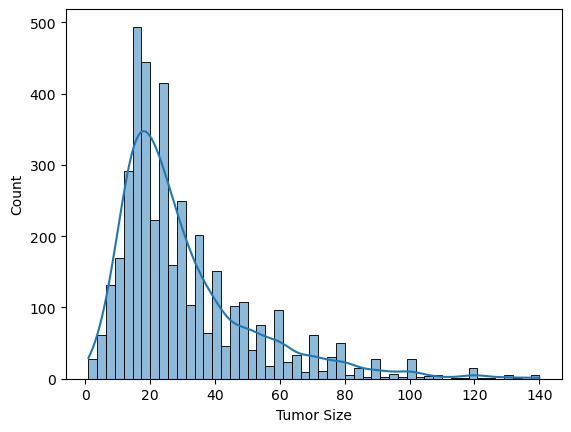

In [13]:
sns.histplot(df["Tumor Size"],kde=True)

plt.show()

# Race vs Status

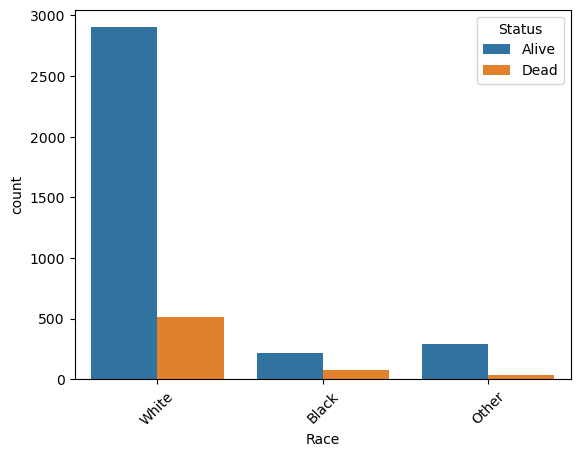

In [14]:
sns.countplot(
x="Race",
hue="Status",
data=df
)

plt.xticks(rotation=45)

plt.show()

# Marital Status

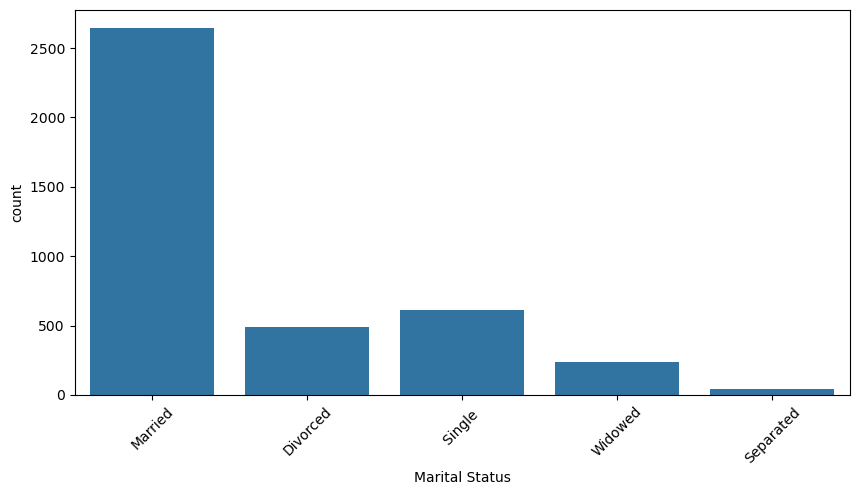

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
x="Marital Status",
data=df
)

plt.xticks(rotation=45)

plt.show()

# Outlier Detection

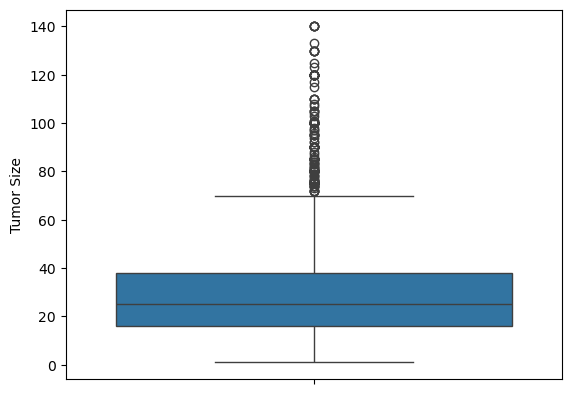

In [16]:
sns.boxplot(df["Tumor Size"])

plt.show()

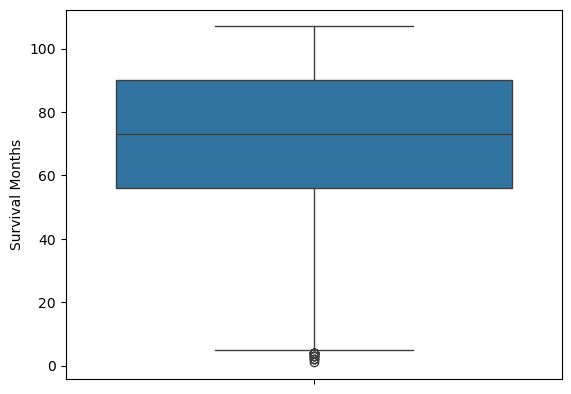

In [17]:
sns.boxplot(df["Survival Months"])

plt.show()

# Remove outlier using IQR:

In [18]:
Q1=df["Tumor Size"].quantile(.25)

Q3=df["Tumor Size"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

df=df[
(df["Tumor Size"]>lower)&
(df["Tumor Size"]<upper)
]

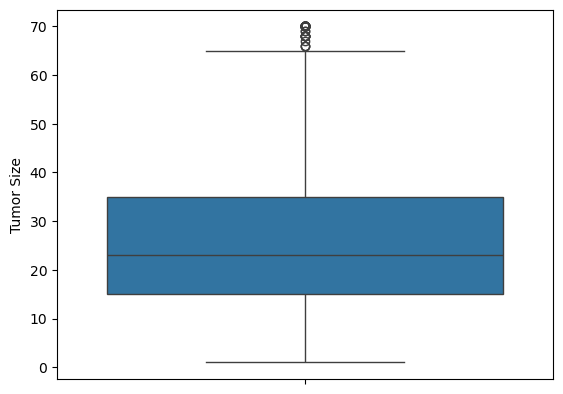

In [19]:
sns.boxplot(df["Tumor Size"])

plt.show()

# Encoding

In [20]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

cat_cols=[
'Race',
'Marital Status',
'T Stage ',
'N Stage',
'6th Stage',
'differentiate',
'Grade',
'A Stage',
'Estrogen Status',
'Progesterone Status',
'Status'
]

for i in cat_cols:
    df[i]=le.fit_transform(df[i])

In [21]:
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,2,1,0,0,0,1,3,1,4,1,1,24,1,60,0
1,50,2,1,1,1,2,0,2,1,35,1,1,14,5,62,0
2,58,2,0,2,2,4,0,2,1,63,1,1,14,7,75,0
3,58,2,1,0,0,0,1,3,1,18,1,1,2,1,84,0
4,47,2,1,1,0,1,1,3,1,41,1,1,3,1,50,0


# Feature and Target

In [22]:
X=df.drop("Status",axis=1)

y=df["Status"]

# Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=\
train_test_split(
X,
y,
test_size=.20,
random_state=42
)

# Feature Scaling

# KNN aur SVM ke liye:

In [24]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()

X_train=sc.fit_transform(X_train)

X_test=sc.transform(X_test)

# Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()

lr.fit(X_train,y_train)

pred1=lr.predict(X_test)

print("Logistic Accuracy:",
      accuracy_score(y_test,pred1))

print(classification_report(y_test,pred1))


Logistic Accuracy: 0.8948751642575559
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       650
           1       0.73      0.44      0.55       111

    accuracy                           0.89       761
   macro avg       0.82      0.71      0.75       761
weighted avg       0.88      0.89      0.88       761



# KNN

In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

pred2=knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test,pred2))

print(classification_report(y_test,pred2))



KNN Accuracy: 0.8777923784494087
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       650
           1       0.63      0.40      0.49       111

    accuracy                           0.88       761
   macro avg       0.77      0.68      0.71       761
weighted avg       0.86      0.88      0.87       761



# Naive Bayes

In [35]:
from sklearn.naive_bayes import GaussianNB

nb=GaussianNB()

nb.fit(X_train,y_train)

pred3=nb.predict(X_test)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test,pred3))

print(classification_report(y_test,pred3))


Naive Bayes Accuracy: 0.8265440210249672
              precision    recall  f1-score   support

           0       0.92      0.87      0.90       650
           1       0.43      0.56      0.48       111

    accuracy                           0.83       761
   macro avg       0.67      0.72      0.69       761
weighted avg       0.85      0.83      0.84       761



# Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred4=dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test,pred4))

print(classification_report(y_test,pred4))


Decision Tree Accuracy: 0.835742444152431
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       650
           1       0.44      0.46      0.45       111

    accuracy                           0.84       761
   macro avg       0.67      0.68      0.68       761
weighted avg       0.84      0.84      0.84       761



# SVM

In [39]:
from sklearn.svm import SVC

svm=SVC()

svm.fit(X_train,y_train)

pred5=svm.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test,pred5))

print(classification_report(y_test,pred5))


SVM Accuracy: 0.9014454664914586
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       650
           1       0.88      0.38      0.53       111

    accuracy                           0.90       761
   macro avg       0.89      0.68      0.74       761
weighted avg       0.90      0.90      0.88       761



# Model Comparison

In [38]:
result=pd.DataFrame({

"Model":[
"Logistic",
"KNN",
"Naive Bayes",
"Decision Tree",
"SVM"
],

"Accuracy":[
accuracy_score(y_test,pred1),
accuracy_score(y_test,pred2),
accuracy_score(y_test,pred3),
accuracy_score(y_test,pred4),
accuracy_score(y_test,pred5)
]

})

print(result)


           Model  Accuracy
0       Logistic  0.894875
1            KNN  0.877792
2    Naive Bayes  0.826544
3  Decision Tree  0.835742
4            SVM  0.901445


# Confusion Matrix

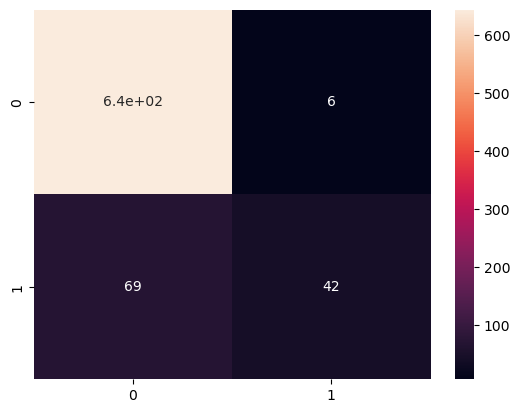

In [33]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,pred5)

sns.heatmap(
cm,
annot=True
)

plt.show()

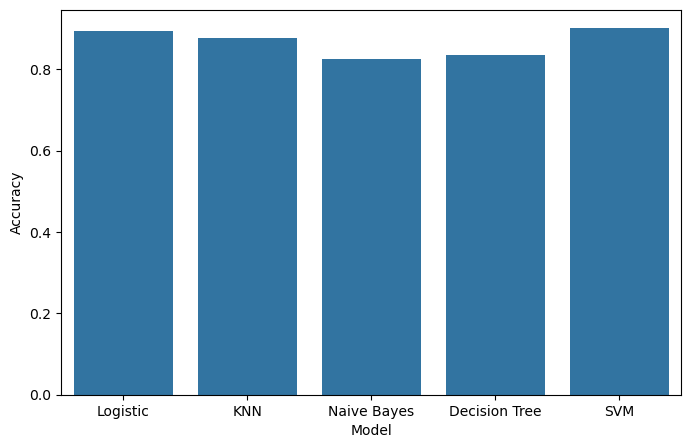

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
x="Model",
y="Accuracy",
data=result
)

plt.show()

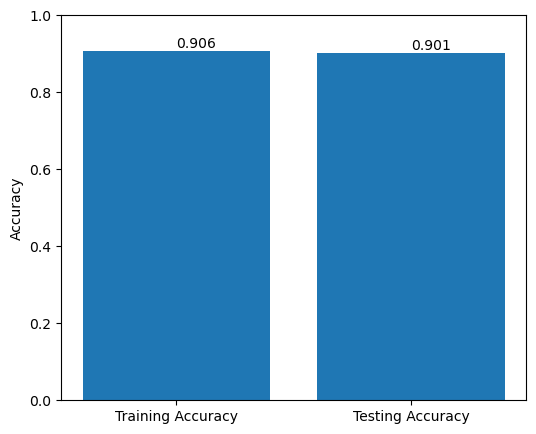

In [36]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Training prediction
train_pred=svm.predict(X_train)

# Testing prediction
test_pred=svm.predict(X_test)

train_acc=accuracy_score(y_train,train_pred)
test_acc=accuracy_score(y_test,test_pred)

plt.figure(figsize=(6,5))

plt.bar(
["Training Accuracy","Testing Accuracy"],
[train_acc,test_acc]
)

plt.ylabel("Accuracy")
plt.ylim(0,1)

for i,v in enumerate([train_acc,test_acc]):
    plt.text(i,v+0.01,round(v,3))

plt.show()